# Digital Data Collection

**Filtering Rows and Convert csv File to json File**

In [ ]:
# Import Libraries
import pandas as pd
from google.colab import files

# Upload Multiple CSV Files
print("Upload your CSV files:")
uploaded_files = files.upload()

# Process Each File
for filename in uploaded_files.keys():
    # Read CSV File
    data = pd.read_csv(filename)

    # Filter Data Where 'source' == 'WEBHIST'
    filtered_data = data[data['source'] == 'WEBHIST']

    # Save Filtered Data to JSON (same name as the CSV file, but with .json extension)
    output_filename = filename.rsplit('.', 1)[0] + '.json'
    filtered_data.to_json(output_filename, orient='records', lines=True)

    # Inform the user and provide the JSON file for download
    print(f"Filtered data saved to {output_filename}. Downloading...")
    files.download(output_filename)


Upload your CSV files:


# Knowledge Representation Modeling

**Merging All Data Rows of Each json File into footprints_df Variable**

In [ ]:
from google.colab import drive
import json
import os
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Initialize variables and load JSON files
folder_path = '/content/drive/My Drive/TA/'
all_data = []

# Load JSON files and assign sequential IDs to footprints
for filename in sorted(os.listdir(folder_path)):
    if filename.endswith('.json'):
        file_path = os.path.join(folder_path, filename)

        with open(file_path) as f:
            data = json.load(f)

            for entry in data.values():
                entry['filename'] = filename
                all_data.append(entry)

# Convert all_data to a DataFrame
footprints_df = pd.DataFrame(all_data)

# Sort the footprints by date_time_min (time start)
footprints_df['date_time_min'] = pd.to_datetime(footprints_df['date_time_min'], errors='coerce') # Ensure proper datetime format
footprints_df['date_time_min'] = footprints_df['date_time_min'].dt.tz_localize(None) # Remove timezone info
footprints_df = footprints_df.sort_values(by='date_time_min').reset_index(drop=True) # Sort and reset index

# Update IDs to make them sequential based on the new order
footprints_df['id'] = footprints_df.index + 1  # Set ID to index + 1 for sequential IDs

# Display the processed footprints for verification
print("Footprints:")
print(footprints_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Footprints:
   id              date_time_min                     date_time_max  \
0   1 2023-12-26 00:36:45.115900  2023-12-26 00:36:45.115900+00:00   
1   2 2023-12-26 00:36:45.132315  2023-12-26 00:36:45.132315+00:00   
2   3 2023-12-26 00:36:45.208631  2023-12-26 00:36:45.208631+00:00   
3   4 2023-12-26 00:36:45.545369  2023-12-26 00:36:45.545369+00:00   
4   5 2023-12-26 00:36:45.545369  2023-12-26 00:36:45.545369+00:00   

                                     evidence_source         type  \
0  Original URL: https://www.bing.com/ck/a?!&&p=d...    Web Visit   
1  https://bing.com/ (MSPTC) Flags: [HTTP only] =...    Web Visit   
2  https://www.bing.com/ck/a?!&&p=dff5510bb42e6e3...    Web Visit   
3  https://www.bing.com/search?form=&q=mozilla+fi...  Bing Search   
4  https://www.bing.com/search?form=&q=mozilla+fi...    Web Visit   

                       

**Extracting Objects, Subjects, and Events from Footprints Based on Type**

Type | Subject | Object |
--- | --- | --- |
Web Visit | Browser | URL |
Process Creation | Executable name | plugin |
Program opened | Program name | plugin |
Recent File Access | File | file_details_from_entry_shell OR file_details_from_lnk |
Google Search | Browser | Search_Term |
Shutdown time | 'Windows' | Windows Event ID |
Bing Search | Browser | Search_Term |
File Downloaded | User | File Name |

In [ ]:
# Initialize lists to store entities
objects = []
subjects = []
events = []

# Define current_id counters for each entity type
object_id = len(footprints_df) + 1
subject_id = object_id + len(footprints_df)
event_id = subject_id + len(footprints_df)

# Define entity extraction function based on type rules
def extract_entities_from_row(row):
    entity_objs = []
    entity_subjs = []
    entity_events = []

    # Rule for "Web Visit"
    if row['type'] == "Web Visit":
        # Subject
        if "Browser" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'browser': row["keys"]["Browser"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if "URL" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'url': row["keys"]["URL"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Process Creation"
    elif row['type'] == "Process Creation":
        # Subject
        if "Executable name" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'executable_name': row["keys"]["Executable name"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if row.get("plugin"):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'plugin': row["plugin"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Program opened"
    elif row['type'] == "Program opened":
        # Subject
        if "Program name" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'program_name': row["keys"]["Program name"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if row.get("plugin"):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'plugin': row["plugin"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Recent File Access"
    elif row['type'] == "Recent File Access":
        # Subject
        if row.get("files"):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'file_path': row["files"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if "file_details_from_lnk" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'file_details_from_lnk': row["keys"].get("file_details_from_lnk")},
                'support': row['id']
            }
            entity_objs.append(object_entity)
        elif "file_details_from_entry_shell" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'file_details_from_entry_shell': row["keys"].get("file_details_from_entry_shell")},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Google Search"
    elif row['type'] == "Google Search":
        # Subject
        if "Browser" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'browser': row["keys"]["Browser"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if "Search_Term" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'search_term': row["keys"]["Search_Term"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Shutdown time"
    elif row['type'] == "Shutdown time":
        # Subject
        subject_entity = {
            'id': subject_id,
            'type': 'Subject',
            'details': {'name': 'Windows'},
            'support': row['id']
        }
        entity_subjs.append(subject_entity)
        # Object
        if "Windows Event ID" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'windows_event_id': row["keys"]["Windows Event ID"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "Bing Search"
    elif row['type'] == "Bing Search":
        # Subject
        if "Browser" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'browser': row["keys"]["Browser"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if "Search_Term" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'search_term': row["keys"]["Search_Term"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Rule for "File Downloaded"
    elif row['type'] == "File Downloaded":
        # Subject
        if "User" in row.get("keys", {}):
            subject_entity = {
                'id': subject_id,
                'type': 'Subject',
                'details': {'user': row["keys"]["User"]},
                'support': row['id']
            }
            entity_subjs.append(subject_entity)
        # Object
        if "File Name" in row.get("keys", {}):
            object_entity = {
                'id': object_id,
                'type': 'Object',
                'details': {'file_name': row["keys"]["File Name"]},
                'support': row['id']
            }
            entity_objs.append(object_entity)

    # Event with subject and object references
    event_entity = {
      'id': event_id,
      'type': row['type'],
      'filename': row['filename'],
      'time': row.get("date_time_min"),
      'subjects': [subj['id'] for subj in entity_subjs],
      'objects': [obj['id'] for obj in entity_objs],
      'related_events': [],
      'support': row['id']  # Link to the footprint ID
    }
    entity_events.append(event_entity)

    return entity_objs, entity_subjs, entity_events

# Process each row in footprints_df and extract entities
for idx, row in footprints_df.iterrows():
    obj_entities, subj_entities, evt_entities = extract_entities_from_row(row)

    objects.extend(obj_entities)
    subjects.extend(subj_entities)
    events.extend(evt_entities)

    # Increment IDs after processing each row
    object_id += len(obj_entities)
    subject_id += len(subj_entities)
    event_id += len(evt_entities)

# Convert entities to DataFrames for final structure
objects_df = pd.DataFrame(objects)
subjects_df = pd.DataFrame(subjects)
events_df = pd.DataFrame(events)

# Display the extracted entities for verification
print("Objects:")
print(objects_df.head())

print("\nSubjects:")
print(subjects_df.head())

print("\nEvents:")
print(events_df.head())

Objects:
    id    type                                            details  support
0  125  Object  {'url': 'https://www.bing.com/ck/a?!&&p=dff551...        1
1  126  Object                       {'url': 'https://bing.com/'}        2
2  127  Object  {'url': 'https://www.bing.com/ck/a?!&&p=dff551...        3
3  128  Object        {'search_term': 'mozilla firefox download'}        4
4  129  Object  {'url': 'https://www.bing.com/search?form=&q=m...        5

Subjects:
    id     type                        details  support
0  249  Subject  {'browser': 'WEBHIST-Chrome'}        1
1  250  Subject  {'browser': 'WEBHIST-Chrome'}        2
2  251  Subject  {'browser': 'WEBHIST-Chrome'}        3
3  252  Subject  {'browser': 'WEBHIST-Chrome'}        4
4  253  Subject  {'browser': 'WEBHIST-Chrome'}        5

Events:
    id         type                           filename  \
0  373    Web Visit  5-firefox-installer-download.json   
1  374    Web Visit  5-firefox-installer-download.json   
2  375    W

**Filtering Duplicate Objects and Subjects**

In [ ]:
# Ensure unique_subjects and unique_objects are populated correctly
unique_subjects = {}
unique_objects = {}

# Process Subjects
for index, row in subjects_df.iterrows():
    details = json.dumps(row['details'], sort_keys=True)  # Convert dict to JSON string
    support = row['support']
    subject_type = row['type']

    # Check if the details already exist in the dictionary
    if details in unique_subjects:
        # Append the support value to the existing entry
        unique_subjects[details]['support'].append(support)
    else:
        # Create a new entry in the dictionary
        unique_subjects[details] = {
            'type': subject_type,
            'support': [support]
        }

# Process Objects
for index, row in objects_df.iterrows():
    details = json.dumps(row['details'], sort_keys=True)  # Convert dict to JSON string
    support = row['support']
    object_type = row['type']

    # Check if the details already exist in the dictionary
    if details in unique_objects:
        # Append the support value to the existing entry
        unique_objects[details]['support'].append(support)
    else:
        # Create a new entry in the dictionary
        unique_objects[details] = {
            'type': object_type,
            'support': [support]
        }

# Convert unique_subjects and unique_objects into DataFrames

# Process unique_objects into a list of dictionaries and reset id sequentially
cleaned_objects_list = []
current_object_id = len(footprints_df) + 1  # Start after the last footprint id
for details, values in unique_objects.items():
    cleaned_objects_list.append({
        'id': current_object_id,  # Reset ID to be sequential from the last footprint ID
        'type': values['type'],
        'details': json.loads(details),  # Convert JSON string back to dictionary
        'aggregated_support': values['support']
    })
    current_object_id += 1

cleaned_objects_df = pd.DataFrame(cleaned_objects_list)

# Process unique_subjects into a list of dictionaries and reset id sequentially
cleaned_subjects_list = []
current_subject_id = current_object_id  # Start after the last object id
for details, values in unique_subjects.items():
    cleaned_subjects_list.append({
        'id': current_subject_id,  # Reset ID to be sequential from the last footprint ID
        'type': values['type'],
        'details': json.loads(details),  # Convert JSON string back to dictionary
        'aggregated_support': values['support']
    })
    current_subject_id += 1

cleaned_subjects_df = pd.DataFrame(cleaned_subjects_list)

# Display the cleaned DataFrames for verification
print("Cleaned Objects:")
print(cleaned_objects_df.head())
print("Max Object ID: ", end='')
print(cleaned_objects_df["id"].max())
print("\nCleaned Subjects:")
print(cleaned_subjects_df.head())
print("Max Subject ID: ", end='')
print(cleaned_subjects_df["id"].max())

Cleaned Objects:
    id    type                                            details  \
0  125  Object  {'url': 'https://www.bing.com/ck/a?!&&p=dff551...   
1  126  Object                       {'url': 'https://bing.com/'}   
2  127  Object  {'url': 'https://www.bing.com/ck/a?!&&p=dff551...   
3  128  Object        {'search_term': 'mozilla firefox download'}   
4  129  Object  {'url': 'https://www.bing.com/search?form=&q=m...   

  aggregated_support  
0                [1]  
1      [2, 118, 119]  
2                [3]  
3            [4, 16]  
4                [5]  
Max Object ID: 232

Cleaned Subjects:
    id     type                         details  \
0  233  Subject   {'browser': 'WEBHIST-Chrome'}   
1  234  Subject     {'program_name': 'cmd.exe'}   
2  235  Subject                {'user': 'User'}   
3  236  Subject  {'program_name': 'uhssvc.exe'}   

                                  aggregated_support  
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...  
1                         

**Updating Values of objects and subjects ​​in events_df Variable**

In [ ]:
# Define the function to map IDs based on support
def map_id_by_support(events_df, cleaned_df, field_name):
    mapped_ids = []
    for support_value in events_df[field_name]:
        # Match support value in cleaned_df
        matching_row = cleaned_df[cleaned_df['aggregated_support'].apply(lambda x: support_value in x)]
        if not matching_row.empty:
            mapped_ids.append(matching_row.iloc[0]['id'])  # Get the corresponding ID
        else:
            mapped_ids.append(None)  # No match found
    return mapped_ids

# Assign sequential IDs to events_df starting from the calculated starting ID
events_df['id'] = range(current_subject_id, current_subject_id + len(events_df))

# Map subject and object IDs using the support field
events_df['subjects'] = map_id_by_support(events_df, cleaned_subjects_df, 'support')
events_df['objects'] = map_id_by_support(events_df, cleaned_objects_df, 'support')

# Display the updated events_df
print("Updated Events:")
print(events_df)

Updated Events:
      id         type                           filename  \
0    237    Web Visit  5-firefox-installer-download.json   
1    238    Web Visit  5-firefox-installer-download.json   
2    239    Web Visit  5-firefox-installer-download.json   
3    240  Bing Search  5-firefox-installer-download.json   
4    241    Web Visit  5-firefox-installer-download.json   
..   ...          ...                                ...   
119  356    Web Visit  5-firefox-installer-download.json   
120  357    Web Visit  5-firefox-installer-download.json   
121  358    Web Visit  5-firefox-installer-download.json   
122  359    Web Visit  5-firefox-installer-download.json   
123  360    Web Visit  5-firefox-installer-download.json   

                          time  subjects  objects related_events  support  
0   2023-12-26 00:36:45.115900       233      125             []        1  
1   2023-12-26 00:36:45.132315       233      126             []        2  
2   2023-12-26 00:36:45.208631     

**Saving All Entities (Footprint, Object, Subject, and Event) to Excel**

In [ ]:
import pandas as pd

# Specify the file path to save the Excel file
file_path = '/content/drive/My Drive/TA/entities.xlsx'

# Create a Pandas Excel writer using openpyxl
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # Write each DataFrame to a separate sheet
    footprints_df.to_excel(writer, sheet_name='Footprints', index=False)
    cleaned_objects_df.to_excel(writer, sheet_name='Objects', index=False)
    cleaned_subjects_df.to_excel(writer, sheet_name='Subjects', index=False)
    events_df.to_excel(writer, sheet_name='Events', index=False)

print(f"Data successfully saved to {file_path}")

Data successfully saved to /content/drive/My Drive/TA/entities.xlsx


**Listing All Entities That Have the Same Support Relationship**

In [ ]:
# Initialize the support variable as a two-dimensional array
support = []

# Process each row in footprints_df to build the support relationships
for idx, row in footprints_df.iterrows():
    footprint_id = row['id']
    related_ids = [footprint_id]  # Start with the footprint ID

    # Extract subject IDs from cleaned_subjects_df using the footprint's support ID
    subject_ids = cleaned_subjects_df.loc[
        cleaned_subjects_df['aggregated_support'].apply(lambda x: footprint_id in x), 'id'
    ].tolist()

    # Extract object IDs from cleaned_objects_df using the footprint's support ID
    object_ids = cleaned_objects_df.loc[
        cleaned_objects_df['aggregated_support'].apply(lambda x: footprint_id in x), 'id'
    ].tolist()

    # Extract event IDs from events_df using the footprint's support field
    event_ids = events_df.loc[events_df['support'] == footprint_id, 'id'].tolist()

    # Add related subject, object, and event IDs to the related_ids list
    related_ids.extend(subject_ids)
    related_ids.extend(object_ids)
    related_ids.extend(event_ids)

    # Append to the support list
    support.append(related_ids)

# Display the support structure for verification
print("Grouped support relationships:")
print(support)
# for s in support:
#     print(s)

Grouped support relationships:
[[1, 233, 125, 237], [2, 233, 126, 238], [3, 233, 127, 239], [4, 233, 128, 240], [5, 233, 129, 241], [6, 233, 130, 242], [7, 233, 131, 243], [8, 233, 132, 244], [9, 233, 133, 245], [10, 233, 134, 246], [11, 233, 135, 247], [12, 233, 136, 248], [13, 233, 137, 249], [14, 233, 138, 250], [15, 233, 139, 251], [16, 233, 128, 252], [17, 233, 130, 253], [18, 233, 140, 254], [19, 233, 141, 255], [20, 233, 142, 256], [21, 233, 143, 257], [22, 233, 144, 258], [23, 233, 145, 259], [24, 233, 146, 260], [25, 233, 147, 261], [26, 233, 148, 262], [27, 233, 149, 263], [28, 233, 150, 264], [29, 233, 151, 265], [30, 233, 152, 266], [31, 233, 153, 267], [32, 233, 154, 268], [33, 233, 155, 269], [34, 233, 156, 270], [35, 233, 157, 271], [36, 233, 158, 272], [37, 233, 159, 273], [38, 233, 160, 274], [39, 233, 161, 275], [40, 233, 162, 276], [41, 233, 163, 277], [42, 233, 164, 278], [43, 233, 165, 279], [44, 233, 166, 280], [45, 233, 167, 281], [46, 233, 168, 282], [47, 233, 1

**Listing Support Relationship in Pairs**

In [ ]:
# Initialize the support_ variable to store only pairs of footprint and single entity IDs
support_ = []

# Iterate through each footprint and extract its related entity IDs
for footprint in footprints_df['id']:
    # Get related subject IDs from cleaned_subjects_df for the current footprint
    subject_ids = cleaned_subjects_df.loc[
        cleaned_subjects_df['aggregated_support'].apply(lambda x: footprint in x), 'id'
    ].tolist()
    for subj_id in subject_ids:
        support_.append([footprint, subj_id])

    # Get related object IDs from cleaned_objects_df for the current footprint
    object_ids = cleaned_objects_df.loc[
        cleaned_objects_df['aggregated_support'].apply(lambda x: footprint in x), 'id'
    ].tolist()
    for obj_id in object_ids:
        support_.append([footprint, obj_id])

    # Get related event IDs from events_df for the current footprint
    event_ids = events_df.loc[events_df['support'] == footprint, 'id'].tolist()
    for evt_id in event_ids:
        support_.append([footprint, evt_id])

# Convert support_ to a DataFrame
support_df = pd.DataFrame(support_, columns=["footprint_id", "entity_id"])

# Save the support relation to an Excel file
support_excel_path = '/content/drive/My Drive/TA/support_relation.xlsx'
with pd.ExcelWriter(support_excel_path, engine='openpyxl') as writer:
    support_df.to_excel(writer, sheet_name='Support', index=False)

# Display the first few rows for verification
print("Support relationships:")
print(support_df.head())

Support relationships:
   footprint_id  entity_id
0             1        233
1             1        125
2             1        237
3             2        233
4             2        126


**Listing Participation Relationship in Pairs**

In [ ]:
# Initialize the participation list to store subject-event relationships
participation = []

# Iterate through the support_ data to identify participation relationships
for support_entry in support_:
    footprint_id = support_entry[0]  # Extract footprint ID
    entity_id = support_entry[1]    # Extract related entity ID

    # Check if the entity is a subject
    if entity_id in cleaned_subjects_df['id'].values:
        # Find related events for the same footprint
        event_ids = events_df.loc[events_df['support'] == footprint_id, 'id'].tolist()

        # Create participation relationships (subject -> event)
        for event_id in event_ids:
            participation.append({
                'subject_id': entity_id,
                'event_id': event_id,
                'footprint_id': footprint_id,  # Optional: Include footprint ID for context
            })

# Convert participation data to a DataFrame for further analysis
participation_df = pd.DataFrame(participation)

# Save participation data to Excel
with pd.ExcelWriter('/content/drive/My Drive/TA/participation_relation.xlsx') as writer:
    participation_df.to_excel(writer, sheet_name='Participation', index=False)

# Display the first few rows for verification
print("Participation relationships:")
print(participation_df.head())

Participation relationships:
   subject_id  event_id  footprint_id
0         233       237             1
1         233       238             2
2         233       239             3
3         233       240             4
4         233       241             5


**Listing Usage Relationship in Pairs**

In [ ]:
# Initialize the usage list to store event-object relationships
usage = []

# Iterate through the support_ data to identify usage relationships
for support_entry in support_:
    footprint_id = support_entry[0]  # Extract footprint ID
    entity_id = support_entry[1]    # Extract related entity ID

    # Check if the entity is an object
    if entity_id in cleaned_objects_df['id'].values:
        # Find related events for the same footprint
        event_ids = events_df.loc[events_df['support'] == footprint_id, 'id'].tolist()

        # Create usage relationships (event -> object)
        for event_id in event_ids:
            usage.append({
                'event_id': event_id,
                'object_id': entity_id,
                'footprint_id': footprint_id,  # Optional: Include footprint ID for context
            })

# Convert usage data to a DataFrame for further analysis
usage_df = pd.DataFrame(usage)

# Save usage data to Excel
with pd.ExcelWriter('/content/drive/My Drive/TA/usage_relation.xlsx') as writer:
    usage_df.to_excel(writer, sheet_name='Usage', index=False)

# Display the first few rows for verification
print("Usage relationships:")
print(usage_df.head())


Usage relationships:
   event_id  object_id  footprint_id
0       237        125             1
1       238        126             2
2       239        127             3
3       240        128             4
4       241        129             5


# Timeline Reconstruction

**Making timeline_df Variable from events_df Variable**

In [ ]:
# Extract necessary columns for the timeline
timeline_df = events_df[["id", "time", "type", "subjects", "objects"]].copy()

# Remove duplicates based on 'time', 'type', 'subjects', and 'objects'
timeline_df = timeline_df.drop_duplicates(subset=["time", "type", "subjects", "objects"]).reset_index(drop=True)

# Display the filtered timeline for verification
print("Timeline")
print(timeline_df.head())

# Save the filtered timeline to Excel for further analysis
timeline_df.to_excel("/content/drive/My Drive/TA/timeline.xlsx", index=False)

Timeline
    id                       time         type  subjects  objects
0  237 2023-12-26 00:36:45.115900    Web Visit       233      125
1  238 2023-12-26 00:36:45.132315    Web Visit       233      126
2  239 2023-12-26 00:36:45.208631    Web Visit       233      127
3  240 2023-12-26 00:36:45.545369  Bing Search       233      128
4  241 2023-12-26 00:36:45.545369    Web Visit       233      129


**Calculating the Correlation Between Each Event**

In [ ]:
# Define temporal relationship functions
def starts(e_start, x_start):
    return int(e_start == x_start)

def equals(e_start, e_end, x_start, x_end):
    return int(e_start == x_start and e_end == x_end)

def meets(e_end, x_start):
    return int(e_end == x_start)

def overlaps(e_start, e_end, x_start, x_end):
    return int(e_start < x_start and e_end > x_start)

def during(e_start, e_end, x_start, x_end):
    return int(e_start > x_start and e_end < x_end)

def finishes(e_end, x_end):
    return int(e_end == x_end)

def before(e_end, x_start):
    # Continuous function for temporal closeness
    if x_start > e_end:
        return 1 / (x_start - e_end).total_seconds()
    else:
        return 0

# Subject and Object Correlations
def subject_correlation(subject_e, subject_x):
    # Ensure subjects are iterable (convert int to list if necessary)
    subject_e = subject_e if isinstance(subject_e, list) else [subject_e]
    subject_x = subject_x if isinstance(subject_x, list) else [subject_x]

    intersection = len(set(subject_e).intersection(set(subject_x)))
    max_size = max(len(subject_e), len(subject_x))
    return intersection / max_size if max_size > 0 else 0

def object_correlation(object_e, object_x):
    # Ensure objects are iterable (convert int to list if necessary)
    object_e = object_e if isinstance(object_e, list) else [object_e]
    object_x = object_x if isinstance(object_x, list) else [object_x]

    intersection = len(set(object_e).intersection(set(object_x)))
    max_size = max(len(object_e), len(object_x))
    return intersection / max_size if max_size > 0 else 0


# Alpha weighting factor
alpha = 1  # Can be adjusted

# Compute all correlations
correlations = []

for i, event1 in timeline_df.iterrows():
    for j, event2 in timeline_df.iterrows():
        if i != j:
            e_start, e_end = event1['time'], event1['time']
            x_start, x_end = event2['time'], event2['time']

            # Temporal correlation
            temporal_corr = (
                alpha * starts(e_start, x_start) +
                alpha * equals(e_start, e_end, x_start, x_end) +
                meets(e_end, x_start) +
                overlaps(e_start, e_end, x_start, x_end) +
                during(e_start, e_end, x_start, x_end) +
                finishes(e_end, x_end) +
                before(e_end, x_start)
            )

            # Subject and Object correlation
            subject_corr = subject_correlation(event1['subjects'], event2['subjects'])
            object_corr = object_correlation(event1['objects'], event2['objects'])

            # Combine correlations
            total_corr = temporal_corr + subject_corr + object_corr

            correlations.append({
                "event1_id": event1["id"],
                "event2_id": event2["id"],
                "temporal_correlation": temporal_corr,
                "subject_correlation": subject_corr,
                "object_correlation": object_corr,
                "total_correlation": total_corr
            })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlations)

# Save to Excel
correlation_df.to_excel("/content/drive/My Drive/TA/correlations.xlsx", index=False)

print("All correlations calculated and saved.")

All correlations calculated and saved.


# Analysis of Relationships Between Events

**Summing the Correlation For Each Event**

In [ ]:
# Aggregate total_correlation for each event1_id
aggregated_correlation_df = (
    correlation_df.groupby("event1_id", as_index=False)
    .agg({
        "total_correlation": "sum"  # Sum all total_correlation for the same event1_id
    })
)

# Rename columns for clarity
aggregated_correlation_df.rename(columns={"total_correlation": "total_correlation_sum"}, inplace=True)

# Sort the DataFrame by total_correlation_sum in descending order
aggregated_correlation_df = aggregated_correlation_df.sort_values(
    by="total_correlation_sum", ascending=False
).reset_index(drop=True)

# Save to Excel
aggregated_correlation_df.to_excel("/content/drive/My Drive/TA/aggregated_correlations_sorted.xlsx", index=False)

# Display the result
print("Aggregated and Sorted Correlations:")
print(aggregated_correlation_df.head())

Aggregated and Sorted Correlations:
   event1_id  total_correlation_sum
0        260           24328.792635
1        259           23306.531394
2        246           20013.822096
3        262           19149.058545
4        256           18772.266974


**Filtering Events Based on Average Correlation of Each Event Type Group**

In [ ]:
# Merge total_correlation_sum into timeline_df based on the id column
timeline_df = timeline_df.merge(
    aggregated_correlation_df,
    left_on="id",
    right_on="event1_id",
    how="left"
)

# Group by "type" and calculate the mean of total_correlation_sum for each group
type_means = timeline_df.groupby("type")["total_correlation_sum"].mean().to_dict()

# Add a new column 'filter' based on the mean for each type
timeline_df["filter"] = timeline_df.apply(
    lambda row: row["total_correlation_sum"] >= type_means[row["type"]]
    if not pd.isna(row["total_correlation_sum"]) else False,
    axis=1
)

# Save the updated timeline_df to Excel for verification
timeline_df.to_excel("/content/drive/My Drive/TA/updated_timeline_with_filter_by_type.xlsx", index=False)

# Display the updated DataFrame
print("Updated timeline_df with 'filter' column grouped by 'type':")
print(timeline_df.head())

Updated timeline_df with 'filter' column grouped by 'type':
    id                       time         type  subjects  objects  event1_id  \
0  237 2023-12-26 00:36:45.115900    Web Visit       233      125        237   
1  238 2023-12-26 00:36:45.132315    Web Visit       233      126        238   
2  239 2023-12-26 00:36:45.208631    Web Visit       233      127        239   
3  240 2023-12-26 00:36:45.545369  Bing Search       233      128        240   
4  241 2023-12-26 00:36:45.545369    Web Visit       233      129        241   

   total_correlation_sum  filter  
0             219.261348   False  
1             162.124332   False  
2             150.524736   False  
3             160.916303   False  
4             159.916303   False  


**Updating timeline_df**

In [ ]:
# Create a new DataFrame with only rows where 'filter' is True
updated_timeline_df = timeline_df[timeline_df["filter"] == True].reset_index(drop=True)

# Save the updated_timeline_df to Excel for further verification
updated_timeline_df.to_excel("/content/drive/My Drive/TA/updated_timeline_filtered.xlsx", index=False)

# Display the filtered DataFrame
print("Updated Timeline (Filtered by 'filter' column):")
print(updated_timeline_df.head())

Updated Timeline (Filtered by 'filter' column):
    id                       time         type  subjects  objects  event1_id  \
0  244 2023-12-26 00:36:46.428764    Web Visit       233      132        244   
1  245 2023-12-26 00:36:46.430239    Web Visit       233      133        245   
2  246 2023-12-26 00:36:46.430367    Web Visit       233      134        246   
3  247 2023-12-26 00:36:46.430446    Web Visit       233      135        247   
4  252 2023-12-26 00:36:46.499242  Bing Search       233      128        252   

   total_correlation_sum  filter  
0            2729.530762    True  
1           16623.990020    True  
2           20013.822096    True  
3           16392.611226    True  
4             171.715597    True  


In [ ]:
# Filter timeline_df berdasarkan kolom 'filter' yang bernilai True
updated_timeline_df = timeline_df[timeline_df["filter"] == True].reset_index(drop=True)

# Tambahkan kolom 'detail_subject' dari cleaned_subjects_df
updated_timeline_df["detail_subject"] = updated_timeline_df["subjects"].map(
    cleaned_subjects_df.set_index("id")["details"]
)

# Tambahkan kolom 'detail_object' dari cleaned_objects_df
updated_timeline_df["detail_object"] = updated_timeline_df["objects"].map(
    cleaned_objects_df.set_index("id")["details"]
)

# Simpan updated_timeline_df ke Excel untuk verifikasi lebih lanjut
updated_timeline_df.to_excel("/content/drive/My Drive/TA/updated_timeline_filtered.xlsx", index=False)

# Tampilkan DataFrame hasil
print("Updated Timeline (Filtered and Enriched):")
print(updated_timeline_df.head())


Updated Timeline (Filtered and Enriched):
    id                       time         type  subjects  objects  event1_id  \
0  244 2023-12-26 00:36:46.428764    Web Visit       233      132        244   
1  245 2023-12-26 00:36:46.430239    Web Visit       233      133        245   
2  246 2023-12-26 00:36:46.430367    Web Visit       233      134        246   
3  247 2023-12-26 00:36:46.430446    Web Visit       233      135        247   
4  252 2023-12-26 00:36:46.499242  Bing Search       233      128        252   

   total_correlation_sum  filter                 detail_subject  \
0            2729.530762    True  {'browser': 'WEBHIST-Chrome'}   
1           16623.990020    True  {'browser': 'WEBHIST-Chrome'}   
2           20013.822096    True  {'browser': 'WEBHIST-Chrome'}   
3           16392.611226    True  {'browser': 'WEBHIST-Chrome'}   
4             171.715597    True  {'browser': 'WEBHIST-Chrome'}   

                                       detail_object  
0  {'url': 'https:/

**Drawing the Timeline Graph**

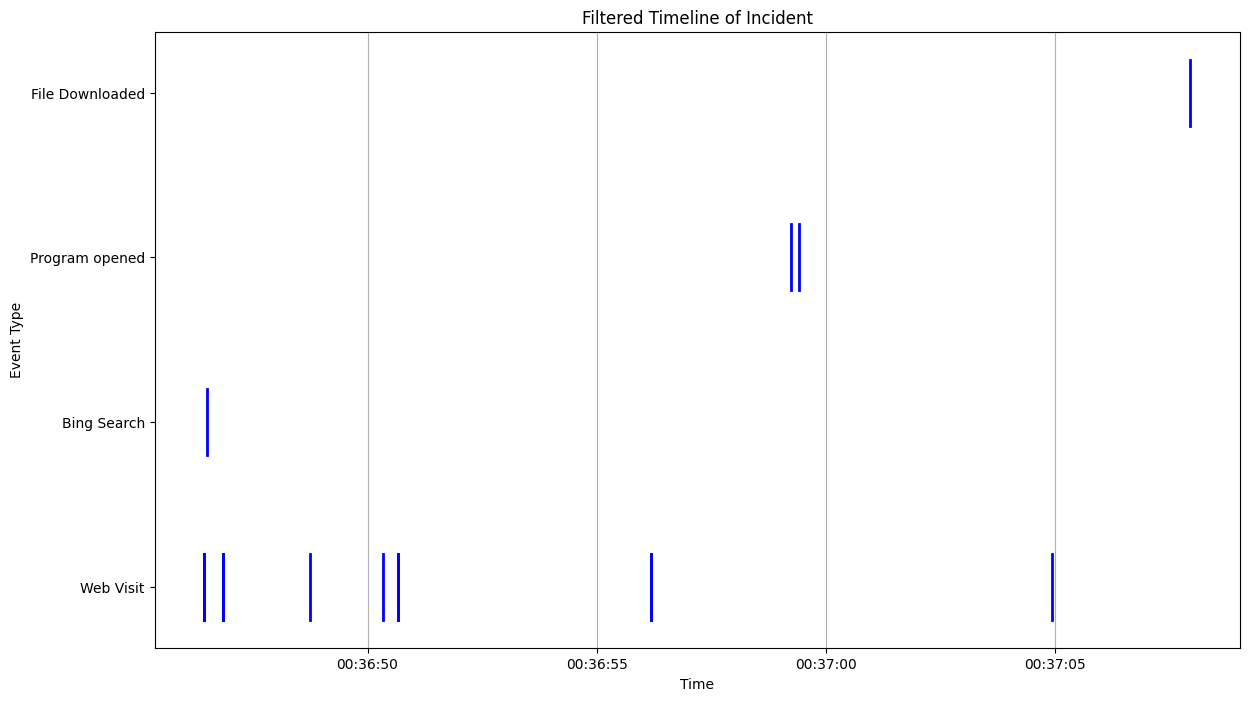

In [ ]:
import matplotlib.pyplot as plt

# Plot the timeline using updated_timeline_df
plt.figure(figsize=(14, 8))

# Map event types to y-axis positions
event_y_positions = {event_type: idx for idx, event_type in enumerate(updated_timeline_df["type"].unique())}
updated_timeline_df["y_position"] = updated_timeline_df["type"].map(event_y_positions)

# Plot each event on the timeline
for _, event in updated_timeline_df.iterrows():
    plt.plot(
        [event["time"], event["time"]],
        [event["y_position"] - 0.2, event["y_position"] + 0.2],
        color="blue", linewidth=2
    )
    plt.text(
        event["time"], event["y_position"],
        f" ",
        horizontalalignment="right",
        fontsize=8
    )

# Label axes
plt.yticks(list(event_y_positions.values()), list(event_y_positions.keys()))
plt.xlabel("Time")
plt.ylabel("Event Type")
plt.title("Filtered Timeline of Incident")
plt.grid(axis="x")

# Save and display the figure
plt.savefig("/content/drive/My Drive/TA/filtered_timeline_incident.png")
plt.show()

**Counting Classification Groups**

In [ ]:
# Count classification groups
print("Event Classifications:")
print(updated_timeline_df["type"].value_counts())

Event Classifications:
type
Web Visit          20
Program opened      2
Bing Search         1
File Downloaded     1
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Path ke file Excel
entities_path = "/content/drive/My Drive/TA/entities.xlsx"
updated_timeline_with_filter_path = "/content/drive/My Drive/TA/updated_timeline_with_filter_by_type.xlsx"
updated_timeline_filtered_path = "/content/drive/My Drive/TA/updated_timeline_filtered.xlsx"

# Baca file entities.xlsx (sheet Events dan Footprints)
events_df = pd.read_excel(entities_path, sheet_name="Events")
footprints_df = pd.read_excel(entities_path, sheet_name="Footprints")

# === Proses untuk updated_timeline_with_filter_by_type.xlsx ===
# Baca updated_timeline_with_filter_by_type.xlsx
updated_timeline_df = pd.read_excel(updated_timeline_with_filter_path)

# Ambil kolom event1_id sebagai x
x = updated_timeline_df["event1_id"]

# Cocokkan x ke kolom id di sheet Events dan ambil kolom support sebagai z
z = x.map(events_df.set_index("id")["support"])

# Cocokkan z ke kolom id di sheet Footprints dan ambil kolom filename sebagai b
b = z.map(footprints_df.set_index("id")["filename"])

# Buat DataFrame baru dengan x dan b
possible_events_df = pd.DataFrame({"event1_id": x, "filename": b})

# === Proses untuk updated_timeline_filtered.xlsx ===
# Baca updated_timeline_filtered.xlsx
updated_timeline_filtered_df = pd.read_excel(updated_timeline_filtered_path)

# Ambil kolom event1_id sebagai x1
x1 = updated_timeline_filtered_df["event1_id"]

# Cocokkan x1 ke kolom id di sheet Events dan ambil kolom support sebagai z1
z1 = x1.map(events_df.set_index("id")["support"])

# Cocokkan z1 ke kolom id di sheet Footprints dan ambil kolom filename sebagai b1
b1 = z1.map(footprints_df.set_index("id")["filename"])

# Buat DataFrame baru dengan x1 dan b1
plausible_inferred_events_df = pd.DataFrame({"event1_id": x1, "filename": b1})

# === Simpan ke file Excel dengan sheet berbeda ===
output_path = "/content/drive/My Drive/TA/events_summary.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    possible_events_df.to_excel(writer, sheet_name="Possible Events", index=False)
    plausible_inferred_events_df.to_excel(writer, sheet_name="Plausible Inferred Events", index=False)

# Verifikasi
print("Possible Events:")
print(possible_events_df.head())
print("\nPlausible Inferred Events:")
print(plausible_inferred_events_df.head())


Possible Events:
   event1_id                           filename
0        237  5-firefox-installer-download.json
1        238  5-firefox-installer-download.json
2        239  5-firefox-installer-download.json
3        240  5-firefox-installer-download.json
4        241  5-firefox-installer-download.json

Plausible Inferred Events:
   event1_id                           filename
0        244  5-firefox-installer-download.json
1        245  5-firefox-installer-download.json
2        246  5-firefox-installer-download.json
3        247  5-firefox-installer-download.json
4        252  5-firefox-installer-download.json


In [ ]:
# Hitung jumlah baris di setiap sheet
total_possible_events = len(possible_events_df)
total_plausible_inferred_events = len(plausible_inferred_events_df)

# Perhitungan global (untuk semua data)
c_global = total_possible_events - total_plausible_inferred_events
fitness_global = 1 - c_global / total_possible_events
generalization_global = total_plausible_inferred_events / total_possible_events

# Buat dictionary untuk menyimpan hasil per file
results = {
    "File": ["All Data"],
    "Fitness": [round(fitness_global, 5)],
    "Generalization": [round(generalization_global, 5)]
}

# List file yang akan dihitung
files_to_check = [
    "2-search-firefox.json",
    "3-launch-cmd.json",
    "4-open-mozilla-org.json",
    "5-firefox-installer-download.json"
]

# Perhitungan untuk setiap file spesifik
for filename in files_to_check:
    # Filter baris berdasarkan filename di setiap sheet
    possible_events_filtered = possible_events_df[possible_events_df["filename"] == filename]
    plausible_inferred_events_filtered = plausible_inferred_events_df[plausible_inferred_events_df["filename"] == filename]

    # Hitung jumlah baris
    a = len(possible_events_filtered)
    b = len(plausible_inferred_events_filtered)
    c = a - b

    # Hindari pembagian dengan nol
    if a > 0:
        fitness = 1 - c / a
        generalization = b / a
    else:
        fitness = 0
        generalization = 0

    # Tambahkan hasil ke dictionary
    results["File"].append(filename)
    results["Fitness"].append(round(fitness, 5))
    results["Generalization"].append(round(generalization, 5))

# Konversi hasil ke DataFrame
results_df = pd.DataFrame(results)

# Simpan hasil ke file Excel
output_path_analysis = "/content/drive/My Drive/TA/events_analysis.xlsx"
with pd.ExcelWriter(output_path_analysis, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="Analysis", index=False)

# Tampilkan hasil
print("Analysis Results:")
print(results_df)


Analysis Results:
                                File  Fitness  Generalization
0                           All Data  0.20168         0.20168
1              2-search-firefox.json  0.00000         0.00000
2                  3-launch-cmd.json  0.00000         0.00000
3            4-open-mozilla-org.json  0.00000         0.00000
4  5-firefox-installer-download.json  0.20168         0.20168
